In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_DIR = Path.cwd()

if (PROJECT_DIR / "data_processed").exists():
    BASE_DIR = PROJECT_DIR
elif (PROJECT_DIR.parent / "data_processed").exists():
    BASE_DIR = PROJECT_DIR.parent
else:
    raise FileNotFoundError("Папка data_processed не найдена ни в текущей папке, ни уровнем выше")

DATA_DIR = BASE_DIR / "data_processed"

print("Текущая папка:", PROJECT_DIR)
print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("Существует ли data_processed:", DATA_DIR.exists())
print("Содержимое data_processed:")
for p in DATA_DIR.iterdir():
    print("-", p.name)

Текущая папка: D:\projects\procurement_analytics_portfolio\notebooks
BASE_DIR: D:\projects\procurement_analytics_portfolio
DATA_DIR: D:\projects\procurement_analytics_portfolio\data_processed
Существует ли data_processed: True
Содержимое data_processed:
- contracts.csv
- contract_items.csv
- customers.csv
- suppliers.csv


In [3]:
contracts = pd.read_csv(
    DATA_DIR / "contracts.csv",
    parse_dates=[
        "contract_date",
        "supplier_selection_result_date",
        "contract_execution_date",
        "last_update_datetime"
    ]
)

contract_items = pd.read_csv(DATA_DIR / "contract_items.csv")

print("contracts shape:", contracts.shape)
print("contract_items shape:", contract_items.shape)

contracts shape: (3851, 25)
contract_items shape: (10701, 7)


In [10]:
contracts.info()

<class 'pandas.DataFrame'>
RangeIndex: 3851 entries, 0 to 3850
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   contract_id                     3851 non-null   int64         
 1   registry_id                     3851 non-null   int64         
 2   customer_name                   3851 non-null   str           
 3   customer_inn                    3851 non-null   int64         
 4   customer_kpp                    3851 non-null   int64         
 5   budget_level                    2088 non-null   str           
 6   budget_name                     2088 non-null   str           
 7   extra_budget_source             1761 non-null   str           
 8   purchase_method                 3851 non-null   str           
 9   notice_number                   2645 non-null   float64       
 10  supplier_selection_result_date  2849 non-null   datetime64[us]
 11  basis_document_

In [4]:
contracts.head()

,contract_id,registry_id,customer_name,customer_inn,customer_kpp,budget_level,budget_name,extra_budget_source,purchase_method,notice_number,supplier_selection_result_date,basis_document_details,contract_date,contract_number,contract_subject,contract_price,budget_code,kosgu,kvr,ikz,supplier_name,supplier_inn,supplier_kpp,last_update_datetime,contract_execution_date
0,1,2051900058824000001,"АДМИНИСТРАЦИЯ МУНИЦИПАЛЬНОГО ОБРАЗОВАНИЯ ""СЕЛЬСОВЕТ КУТУЛЬСКИЙ"" КУРАХСКОГО РАЙОНА РЕСПУБЛИКИ ДАГЕСТАН",519000588,51901001,Местный бюджет,"Бюджет муниципального образования ""сельсовет Кутульский"" Курахского района Республики Дагестан",NaN,"Закупка у единственного поставщика (подрядчика, исполнителя)",NaN,2023-12-21,Муниципальный контракт на поставку газа 12-6-12/10-0134/24К,2024-01-01,12-6-12/10-0134/24К,Муниципальный контракт на поставку газа,36559.45,001-0104-8830020000-247,NaN,247,242051900058805190100100010010620247,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАЗПРОМ МЕЖРЕГИОНГАЗ МАХАЧКАЛА""",0571008854,057101001,2024-04-22 21:48:00,2024-12-31
1,2,3050000090824000001,"МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ БЛАГОУСТРОЙСТВА, ОЗЕЛЕНЕНИЯ И ЖИЛИЩНО-КОММУНАЛЬНОГО ХОЗЯЙСТВА"" АДМИНИ...",500000908,50001001,NaN,NaN,Средства бюджетных учреждений,"Закупка у единственного поставщика (подрядчика, исполнителя)",NaN,NaT,NaN,2024-01-01,1,Содержание христианского кладбища г.Кизилюрта,50106.00,NaN,NaN,244,243050000090805000100100100019603244,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЖКХ ПОС. СУЛАК""",0546022630,054601001,2024-04-04 15:04:00,2024-12-31
2,3,3050000090824000002,"МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ БЛАГОУСТРОЙСТВА, ОЗЕЛЕНЕНИЯ И ЖИЛИЩНО-КОММУНАЛЬНОГО ХОЗЯЙСТВА"" АДМИНИ...",500000908,50001001,NaN,NaN,Средства бюджетных учреждений,"Закупка у единственного поставщика (подрядчика, исполнителя)",NaN,NaT,NaN,2024-01-01,2,Санитарное содержание контейнерных площадок г.Кизилюрт,330701.00,NaN,NaN,244,243050000090805000100100120018129244,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЖКХ ПОС. СУЛАК""",0546022630,054601001,2024-04-04 15:03:00,2024-12-31
3,4,3050000090824000003,"МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ БЛАГОУСТРОЙСТВА, ОЗЕЛЕНЕНИЯ И ЖИЛИЩНО-КОММУНАЛЬНОГО ХОЗЯЙСТВА"" АДМИНИ...",500000908,50001001,NaN,NaN,Средства бюджетных учреждений,"Закупка у единственного поставщика (подрядчика, исполнителя)",NaN,NaT,NaN,2024-01-01,3,"Санитарная уборка территории ГО ""город Кизилюрт""",2805750.00,NaN,NaN,244,243050000090805000100100110018129244,"ПРОИЗВОДСТВЕННЫЙ КООПЕРАТИВ ""ПИОНЕР""",0546010708,054601001,2024-04-04 15:03:00,2024-12-31
4,5,3050001100024000001,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""ОТДЕЛ ОБРАЗОВАНИЯ МУНИЦИПАЛЬНОГО ОБРАЗОВАНИЯ ""ХИВСКИЙ РАЙОН""",500011000,50001001,Местный бюджет,"Бюджет Муниципального Образования ""Хивский район"" Республики Дагестан",NaN,"Закупка у единственного поставщика (подрядчика, исполнителя)",NaN,NaT,"Закупка оказания услуг по водоснабжению, водоотведению, теплоснабжению, обращению с твердыми коммунальными отходами,...",2024-01-01,12-6-36/01-0702/24K,"Поставщик обязуется поставлять с 01.01.2024 по З1.12.2024г. газ, а Покупатель получать (выбирать) и оплачивать Поста...",1334218.02,"001-0702-4210099000-247,001-0701-4220099000-247",NaN,247 247,243050001100005000100100010013523247,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАЗПРОМ МЕЖРЕГИОНГАЗ МАХАЧКАЛА""",0571008854,057101001,2025-12-04 10:23:00,2024-12-31


In [5]:
#просмотрим структуру
contract_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 10701 entries, 0 to 10700
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item_id          10701 non-null  int64  
 1   registry_id      10701 non-null  int64  
 2   item_name        10701 non-null  str    
 3   item_code        10701 non-null  str    
 4   item_unit_price  10691 non-null  float64
 5   item_quantity    5367 non-null   float64
 6   item_amount      5431 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 585.3 KB


In [6]:
contract_items.head(3)

,item_id,registry_id,item_name,item_code,item_unit_price,item_quantity,item_amount
0,1,3057301873824000002,Электроснабжение,35.12.10.110,7.00,1.800000e+05,1260000.00
1,2,3056206854324000001,Поставка тепловой энергии и теплоноситель,35.30.11.120,3742.06,2.483764e+02,929438.28
2,3,3054100850424000014,Покупка-продажа электрической энергии уличное освещение,35.11.10.112,6.57,3.805175e+06,25000000.00


In [7]:
#Проверим пропуски для контрактов
(contracts.isna().mean() * 100).sort_values(ascending=False).round(2)

kosgu                             100.00
extra_budget_source                54.27
budget_code                        45.78
budget_level                       45.78
budget_name                        45.78
basis_document_details             38.46
notice_number                      31.32
supplier_kpp                       29.47
supplier_selection_result_date     26.02
contract_number                     0.39
contract_id                         0.00
last_update_datetime                0.00
supplier_inn                        0.00
supplier_name                       0.00
ikz                                 0.00
kvr                                 0.00
contract_date                       0.00
contract_price                      0.00
contract_subject                    0.00
registry_id                         0.00
purchase_method                     0.00
customer_kpp                        0.00
customer_inn                        0.00
customer_name                       0.00
contract_executi

In [24]:
#Проверим пропуски для позиций
(contract_items.isna().mean() * 100).sort_values(ascending=False).round(2)

item_quantity      49.85
item_amount        49.25
item_unit_price     0.09
item_id             0.00
registry_id         0.00
item_name           0.00
item_code           0.00
dtype: float64

In [8]:
#Найдем основные KPI
contracts_count = contracts["registry_id"].nunique()
total_contract_value = contracts["contract_price"].sum()
avg_contract_value = contracts["contract_price"].mean()
median_contract_value = contracts["contract_price"].median()
min_contract_value = contracts["contract_price"].min()
max_contract_value = contracts["contract_price"].max()

print(f"Количество контрактов: {contracts_count:,}")
print(f"Общая сумма контрактов: {total_contract_value:,.2f}")
print(f"Средняя сумма контракта: {avg_contract_value:,.2f}")
print(f"Медианная сумма контракта: {median_contract_value:,.2f}")
print(f"Минимальная сумма контракта: {min_contract_value:,.2f}")
print(f"Максимальная сумма контракта: {max_contract_value:,.2f}")

Количество контрактов: 3,851
Общая сумма контрактов: 13,078,313,474.30
Средняя сумма контракта: 3,396,082.44
Медианная сумма контракта: 524,500.00
Минимальная сумма контракта: 0.00
Максимальная сумма контракта: 1,298,896,711.00


In [9]:
#TOP 10 заказчиков по сумме контрактов
top_customers = (
    contracts.groupby("customer_name", dropna=False)["contract_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

customer_name
МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ "УПРАВЛЕНИЕ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА" ГОРОДСКОГО ОКРУГА "ГОРОД ДЕРБЕНТ"                2.967493e+09
МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ " УПРАВЛЕНИЕ ЖИЛИЩНО-КОММУНАЛЬНОГО ХОЗЯЙСТВА ГОРОДА МАХАЧКАЛА "                          9.634197e+08
МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ "ДЕПАРТАМЕНТ СОЦИАЛЬНОГО ПИТАНИЯ ГОРОДА МАХАЧКАЛЫ"                                       5.854986e+08
МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ "БЛАГОУСТРОЙСТВО ГОРОДА МАХАЧКАЛЫ"                                                      4.089889e+08
МУНИЦИПАЛЬНОЕ УЧРЕЖДЕНИЕ "УПРАВЛЕНИЕ ТРАНСПОРТА,СВЯЗИ И ДОРОЖНОГО ХОЗЯЙСТВА АДМИНИСТРАЦИИ ГОРОДА МАХАЧКАЛЫ"                3.432425e+08
МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ "УПРАВЛЕНИЕ СТРОИТЕЛЬСТВА И ЕДИНОГО ЗАКАЗЧИКА" МУНИЦИПАЛЬНЫЙ РАЙОН "АХТЫНСКИЙ РАЙОН"    3.202996e+08
АДМИНИСТРАЦИЯ МУНИЦИПАЛЬНОГО РАЙОНА "ЛАКСКИЙ РАЙОН"                                                                        3.071434e+08
МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ 

C:\Users\Akhmedhan\AppData\Local\Temp\ipykernel_21568\3209492833.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


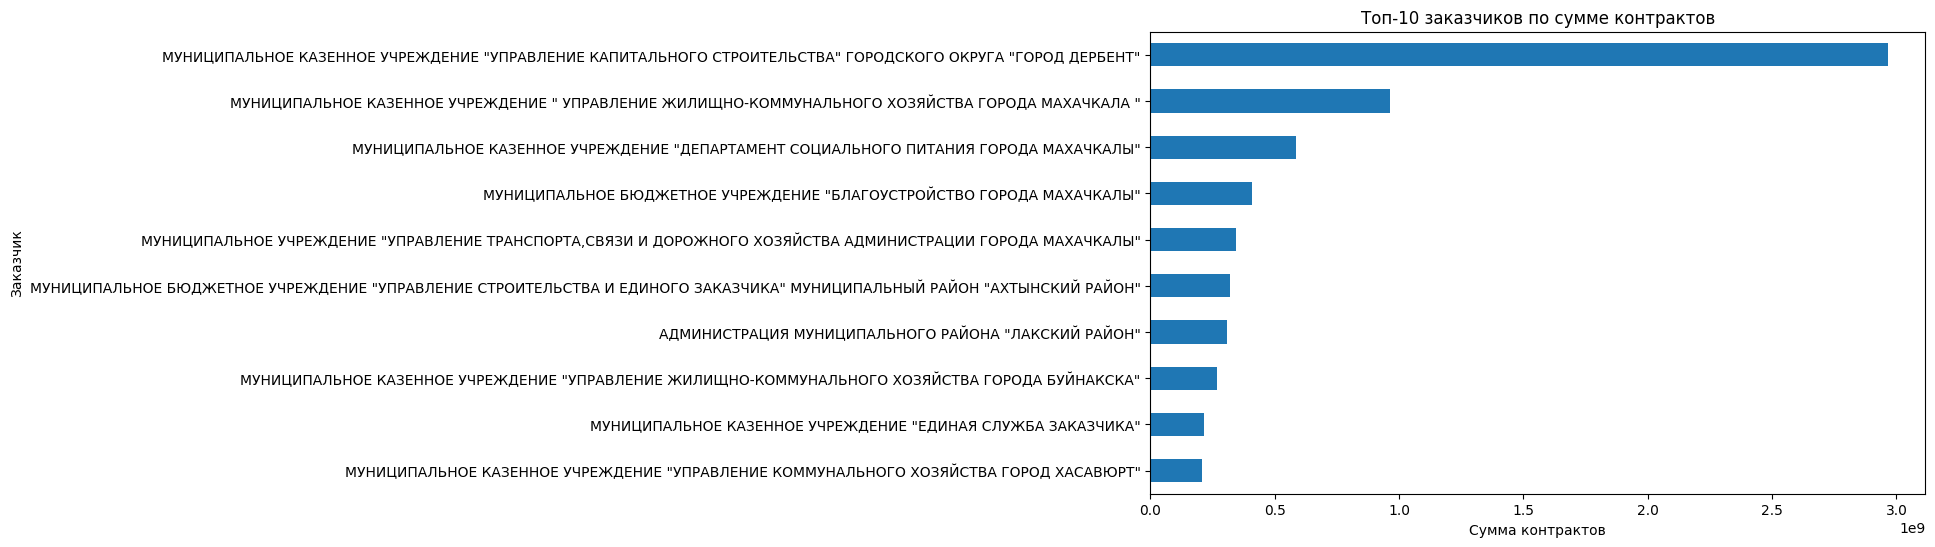

In [10]:
top_customers.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Топ-10 заказчиков по сумме контрактов")
plt.xlabel("Сумма контрактов")
plt.ylabel("Заказчик")
plt.tight_layout()
plt.savefig("../dashboard/top_customers.png", bbox_inches="tight")
plt.show()

Вывод
Наибольший объем контрактов сосредоточен у ограниченного числа заказчиков. 
Это указывает на концентрацию закупочной активности и позволяет выделить ключевых заказчиков для последующего более детального анализа структуры расходов.


In [11]:
###TOP 10 поставщиков по сумме контрактов###
top_suppliers = (
    contracts.groupby("supplier_name", dropna=False)["contract_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_suppliers

supplier_name
ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ЮЖГАЗСТРОЙ"                                               1.298897e+09
ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СТРОИТЕЛЬНАЯ КОМПАНИЯ-05"                                 8.898140e+08
ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "МОНОЛИТ-ГРУПП"                                            3.522880e+08
ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ЭКСПРЕСС-ПРОДУКТ"                                         3.327942e+08
ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "РЕГИОН СТРОЙ"                                             2.780842e+08
АКЦИОНЕРНОЕ ОБЩЕСТВО "ЕДИНЫЙ ОПЕРАТОР РЕСПУБЛИКИ ДАГЕСТАН В СФЕРЕ ВОДОСНАБЖЕНИЯ И ВОДООТВЕДЕНИЯ"    2.697891e+08
ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО "ЮГМОНТАЖСПЕЦСТРОЙ"                                                   2.650000e+08
ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ПИКСТРОЙ"                                                 2.639494e+08
ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ФИРМА " МАЯК"                            

C:\Users\Akhmedhan\AppData\Local\Temp\ipykernel_21568\104623171.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


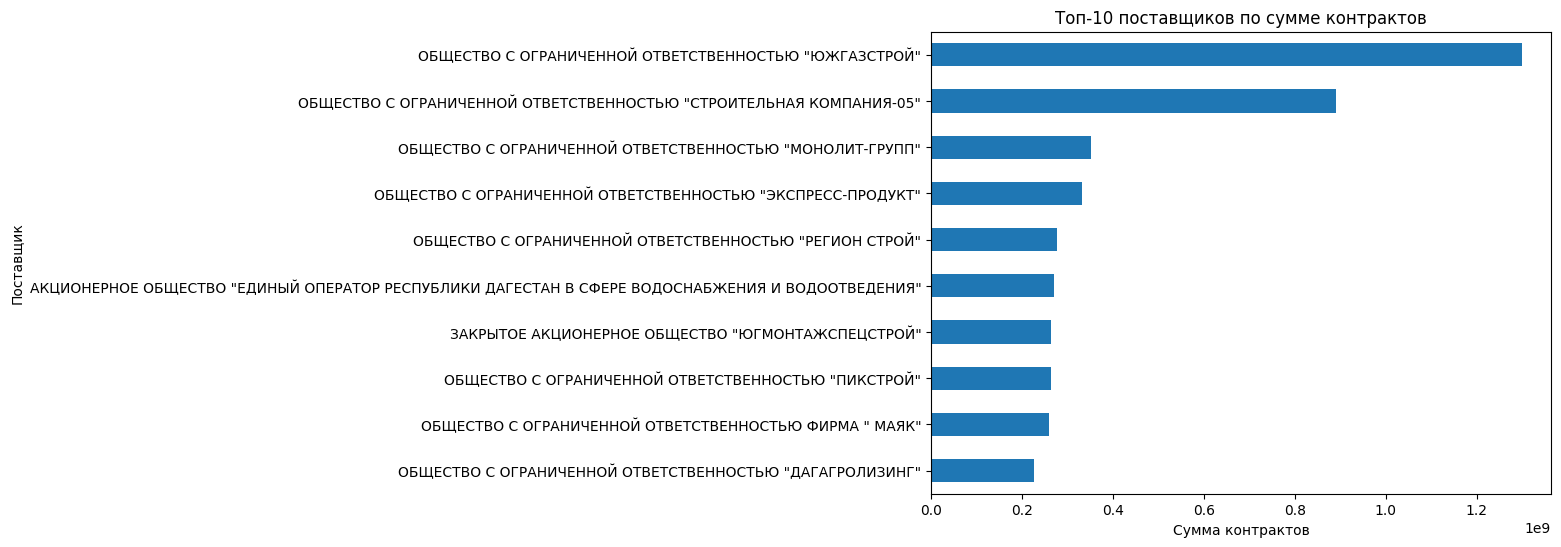

In [15]:
top_suppliers.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Топ-10 поставщиков по сумме контрактов")
plt.xlabel("Сумма контрактов")
plt.ylabel("Поставщик")
plt.tight_layout()
plt.savefig("../dashboard/top_suppliers.png", bbox_inches="tight")
plt.show()

Вывод:
Среди поставщиков также наблюдается концентрация по сумме контрактов. 
Это позволяет выделить крупнейших контрагентов и в дальнейшем оценить их долю в общем объеме закупок.

In [16]:
#Самые дорогие контракты 
contracts.nlargest(10, "contract_price")[
    [
        "registry_id",
        "customer_name",
        "supplier_name",
        "contract_subject",
        "contract_price",
        "contract_date"
    ]
]

,registry_id,customer_name,supplier_name,contract_subject,contract_price,contract_date
1357,3054201850524000005,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА"" ГОРОДСКОГО ОКРУГА ""ГОРОД ДЕРБЕНТ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЮЖГАЗСТРОЙ""",Реконструкция городских улиц с заменой/реконструкцией инженерных коммуникаций улиц Тахо-Годи - Красная Заря - Г. Дал...,1.298897e+09,2024-03-13
2409,3054201850524000010,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА"" ГОРОДСКОГО ОКРУГА ""ГОРОД ДЕРБЕНТ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРОИТЕЛЬНАЯ КОМПАНИЯ-05""",Строительство набережной в г. Дербенте,8.898140e+08,2024-06-05
2844,3052000382624000007,"АДМИНИСТРАЦИЯ МУНИЦИПАЛЬНОГО РАЙОНА ""ЛАКСКИЙ РАЙОН""","ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""ЮГМОНТАЖСПЕЦСТРОЙ""","Реконструкция группового водопровода ""Хулисма-Кумух"" Лакского района Республики Дагестан",2.650000e+08,2024-08-05
1095,3054201850524000002,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА"" ГОРОДСКОГО ОКРУГА ""ГОРОД ДЕРБЕНТ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ФИРМА "" МАЯК""",Мероприятия по развитию улично-дорожной сети: реконструкция улицы Дрожжина - Гырхлар-Капы в г. Дербенте Республики Д...,2.257223e+08,2024-02-26
645,3054100850424000002,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ "" УПРАВЛЕНИЕ ЖИЛИЩНО-КОММУНАЛЬНОГО ХОЗЯЙСТВА ГОРОДА МАХАЧКАЛА ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""МАХАЧКАЛИНСКАЯ ДПМК""",Работы по ремонту автомобильных дорог в 2024 году,2.125956e+08,2024-01-22
1241,3054201850524000003,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА"" ГОРОДСКОГО ОКРУГА ""ГОРОД ДЕРБЕНТ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АРЭМ""",Мероприятия по развитию улично-дорожной сети: реконструкция улицы Аваин-Булаг в г. Дербенте Республики Дагестан,1.946115e+08,2024-03-04
1266,3054201850524000004,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА"" ГОРОДСКОГО ОКРУГА ""ГОРОД ДЕРБЕНТ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПИКСТРОЙ""",Реконструкция улицы Строительная в г. Дербенте Республики Дагестан,1.835558e+08,2024-03-06
282,3054100850424000001,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ "" УПРАВЛЕНИЕ ЖИЛИЩНО-КОММУНАЛЬНОГО ХОЗЯЙСТВА ГОРОДА МАХАЧКАЛА ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТРОЙАВТОДОР""",Работы по ремонту автомобильных дорог в г. Махачкала,1.774380e+08,2024-01-08
2949,3056207700124000006,"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""ФИНАНСОВОЕ УПРАВЛЕНИЕ"" АДМИНИСТРАЦИИ ГОРОДСКОГО ОКРУГА ""ГОРОД МАХАЧКАЛА""","ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО ""СБЕРБАНК РОССИИ""",Услуги по предоставлению кредитов финансовыми организациями юридическим лицам,1.650050e+08,2024-08-23
3120,3053301005924000011,"АДМИНИСТРАЦИЯ МУНИЦИПАЛЬНОГО ОБРАЗОВАНИЯ "" УНЦУКУЛЬСКИЙ РАЙОН ""","ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ЮГГИДРОТЕХНОСЕРВИС""",Реконструкция водопроводных сетей в пос. Шамилькала Унцукульского района,1.150000e+08,2024-09-09


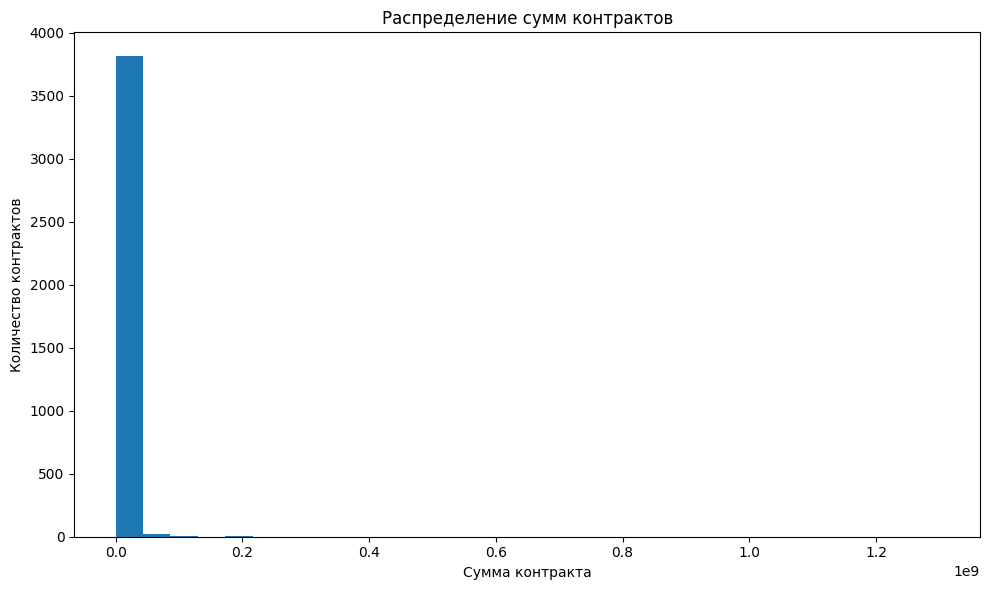

In [17]:
#График распределения сумм контрактов
plt.figure(figsize=(10, 6))
contracts["contract_price"].dropna().plot(kind="hist", bins=30)
plt.title("Распределение сумм контрактов")
plt.xlabel("Сумма контракта")
plt.ylabel("Количество контрактов")
plt.tight_layout()
plt.show()

Вывод:
Распределение сумм контрактов имеет выраженную правостороннюю асимметрию: в датасете преобладают контракты с относительно небольшой стоимостью, тогда как крупные контракты встречаются значительно реже. 
Поэтому для анализа таких данных важно использовать не только среднее значение, но и медиану, а также дополнительные визуализации для крупных контрактов.

In [18]:
#Найдем и выведем информацию по способам закупок
purchase_method_stats = (
    contracts.groupby("purchase_method", dropna=False)
    .agg(
        contracts_count=("registry_id", "count"),
        total_value=("contract_price", "sum")
    )
    .sort_values("total_value", ascending=False)
)

purchase_method_stats.head(10)

,contracts_count,total_value
purchase_method,,
Открытый конкурс в электронной форме,831,5.358363e+09
"Открытый конкурс в электронной форме на проведение работ по строительству, реконструкции, кап. ремонту, сносу объекта кап. строительства в соответствии с п. 8 ч. 1 ст. 33 Закона № 44-ФЗ",198,4.546408e+09
Электронный аукцион,787,1.439091e+09
"Закупка у единственного поставщика (подрядчика, исполнителя)",1201,1.020421e+09
"Закупка, осуществляемая в соответствии с частью 12 статьи 93 Закона № 44-ФЗ",616,3.587751e+08
Запрос котировок в электронной форме,173,2.436782e+08
"Электронный аукцион на проведение работ по строительству, реконструкции, кап. ремонту, сносу объекта кап. строительства в соответствии с п. 8 ч. 1 ст. 33 Закона № 44-ФЗ",34,8.969344e+07
"Способ определения поставщика (подрядчика, исполнителя), установленный Правительством Российской Федерации в соответствии со ст. 111 Федерального закона № 44-ФЗ",5,1.188612e+07
"Запрос котировок в электронной форме на проведение работ по строительству, реконструкции, кап. ремонту, сносу объекта кап. строительства в соответствии с п. 8 ч. 1 ст. 33 Закона № 44-ФЗ",6,9.997274e+06


C:\Users\Akhmedhan\AppData\Local\Temp\ipykernel_7936\1119709522.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


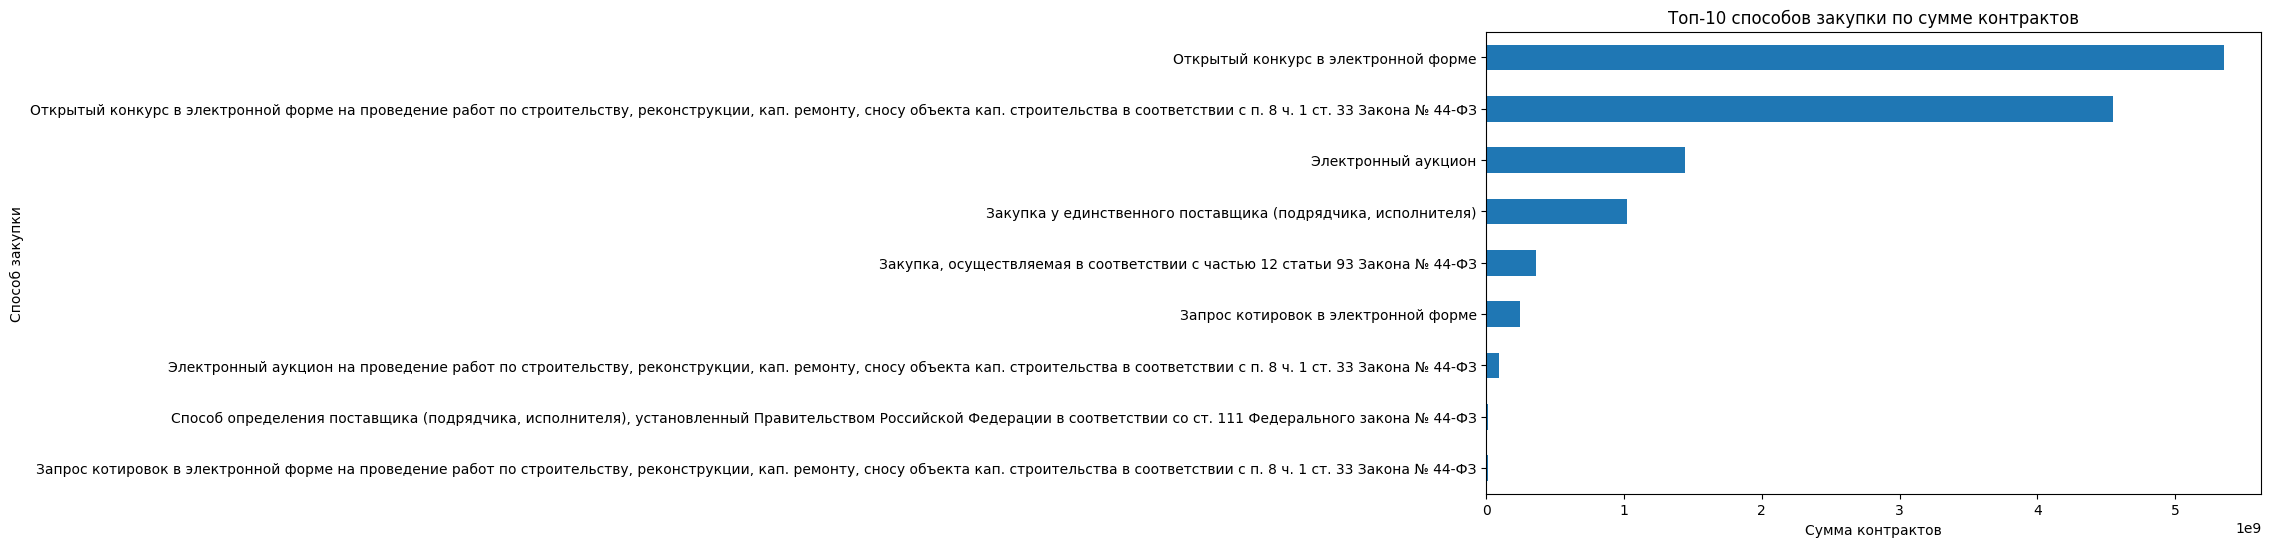

In [41]:
purchase_method_stats["total_value"].head(10).sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Топ-10 способов закупки по сумме контрактов")
plt.xlabel("Сумма контрактов")
plt.ylabel("Способ закупки")
plt.tight_layout()
plt.show()

Вывод: Основной объем контрактов формируется ограниченным числом способов закупки. Этот разрез важен для понимания структуры закупочной деятельности и последующей оценки концентрации контрактов по закупочным процедурам.

ДИНАМИКА ПО МЕСЯЦАМ

In [19]:
#СОздадим месяц контракта
contracts["contract_month"] = contracts["contract_date"].dt.to_period("M").astype(str)

In [20]:
#Проведем агрегацию
monthly_stats = (
    contracts.groupby("contract_month")
    .agg(
        contracts_count=("registry_id", "count"),
        total_value=("contract_price", "sum")
    )
    .reset_index()
    .sort_values("contract_month")
)

monthly_stats

,contract_month,contracts_count,total_value
0,2024-01,869,1.257517e+09
1,2024-02,306,6.345529e+08
2,2024-03,520,3.259421e+09
3,2024-04,376,1.019725e+09
4,2024-05,288,1.212132e+09
5,2024-06,221,2.000228e+09
6,2024-07,243,7.840448e+08
7,2024-08,215,9.204587e+08
8,2024-09,191,8.362747e+08
9,2024-10,189,3.452088e+08


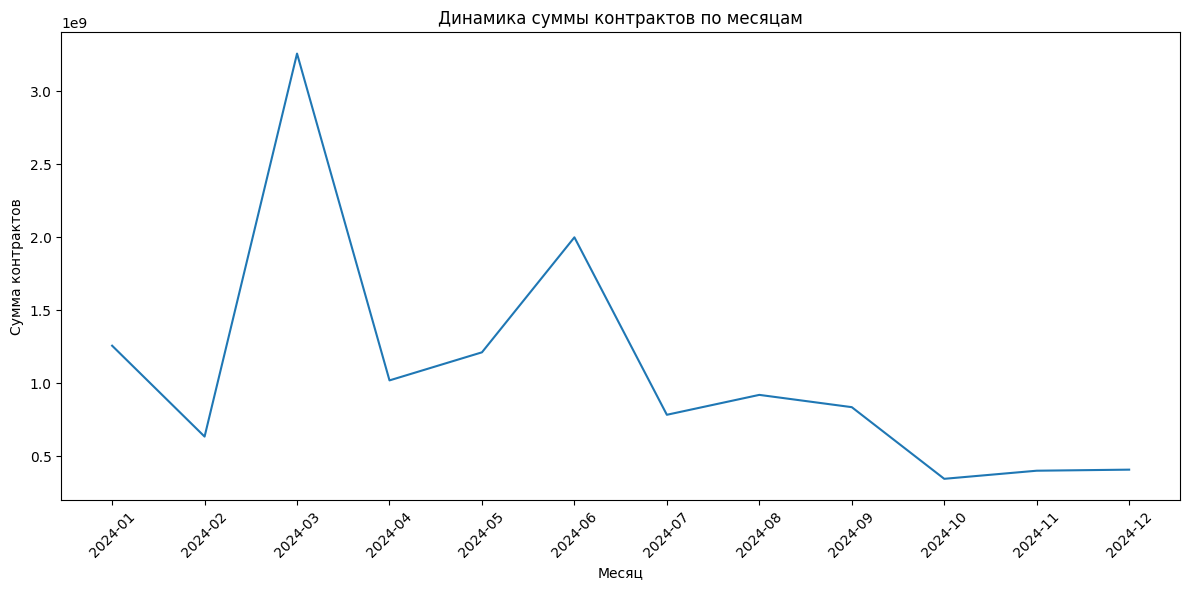

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_stats["contract_month"], monthly_stats["total_value"])
plt.title("Динамика суммы контрактов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Сумма контрактов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../dashboard/monthly_dynamics.png", bbox_inches="tight")
plt.show()

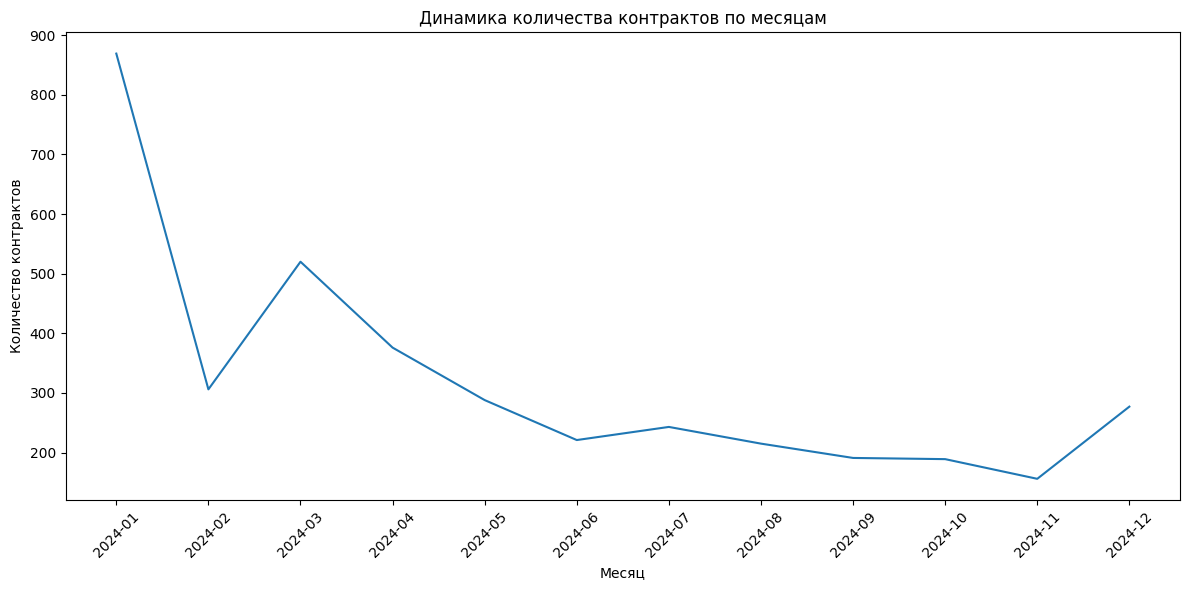

In [48]:
#Далее график по количеству
plt.figure(figsize=(12, 6))
plt.plot(monthly_stats["contract_month"], monthly_stats["contracts_count"])
plt.title("Динамика количества контрактов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество контрактов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Вывод: Помесячная динамика позволяет оценить сезонность закупочной активности, выявить периоды пиковых закупок и сравнить изменение количества контрактов с изменением общего объема контрактных сумм.

In [50]:
### TOP объектов закупки по сумме
top_items = (
    contract_items.groupby("item_name", dropna=False)["item_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_items

item_name
Реконструкция городских улиц с заменой/реконструкцией инженерных коммуникаций улиц Тахо-Годи - Красная Заря - Г. Далгата - Шеболдаева в городе Дербенте Республики Дагестан    1.298897e+09
Строительство набережной в г. Дербенте                                                                                                                                         8.898140e+08
Работы строительные специализированные прочие, не включенные в другие группировки                                                                                              5.321914e+08
Работы по ремонту автомобильных дорог                                                                                                                                          4.423148e+08
Услуга по регулярным перевозкам пассажиров автобусом                                                                                                                           3.395725e+08
Дороги автомобильные, в том числе улично-дорожная 

C:\Users\Akhmedhan\AppData\Local\Temp\ipykernel_7936\1114816874.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


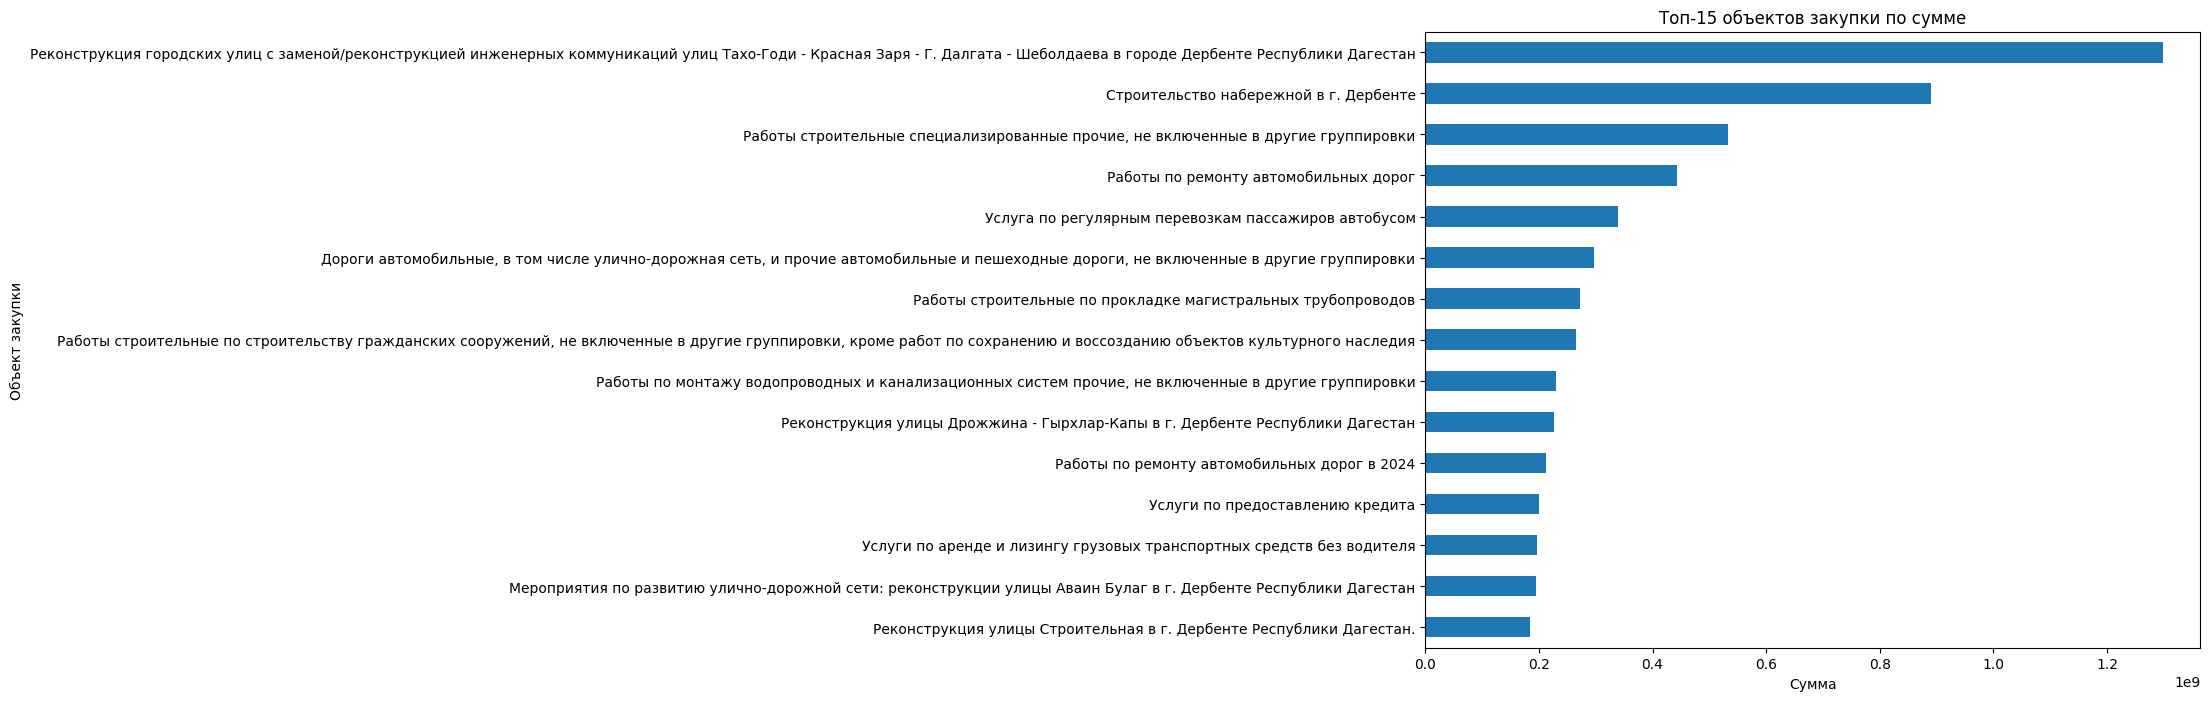

In [51]:
top_items.sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Топ-15 объектов закупки по сумме")
plt.xlabel("Сумма")
plt.ylabel("Объект закупки")
plt.tight_layout()
plt.show()

Вывод: Анализ объектов закупки показывает, какие товары, работы и услуги формируют наибольшую долю расходов. Это помогает выявить ключевые направления закупочной активности.

In [53]:
##Самые частые по кол-ву объекты закупок
top_items_by_count = contract_items["item_name"].value_counts(dropna=False).head(15)
top_items_by_count

item_name
Поставка газа                                                                                                                             129
Услуги по обеспечению питанием, осуществляемые по договору, прочие                                                                         92
Яблоки                                                                                                                                     85
Бананы                                                                                                                                     84
Дороги автомобильные, в том числе улично-дорожная сеть, и прочие автомобильные и пешеходные дороги, не включенные в другие группировки     71
Услуги по передаче электроэнергии                                                                                                          67
Хлеб ржаной                                                                                                                               

C:\Users\Akhmedhan\AppData\Local\Temp\ipykernel_7936\3386219364.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


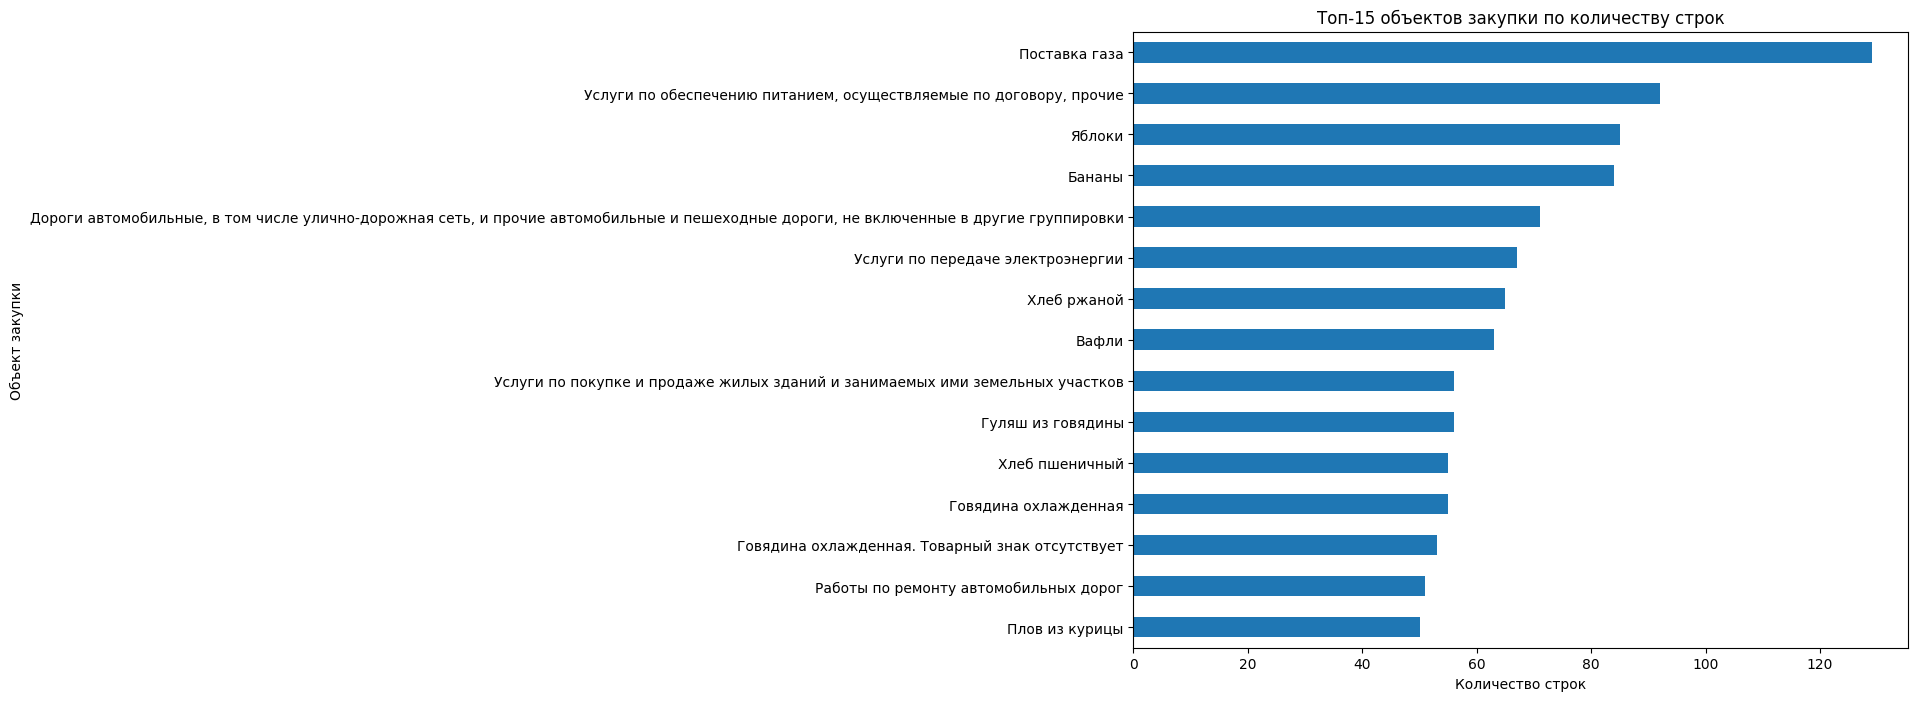

In [54]:
top_items_by_count.sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Топ-15 объектов закупки по количеству строк")
plt.xlabel("Количество строк")
plt.ylabel("Объект закупки")
plt.tight_layout()
plt.show()

Вывод: Наиболее частые объекты закупки не всегда совпадают с наиболее дорогими. Это позволяет разделить массовые закупки и закупки, формирующие основной финансовый объем.

In [57]:
#Проверка качества данных: суммы контрактов и позиций
contracts_sum = contracts["contract_price"].sum()
items_sum = contract_items["item_amount"].sum()

print("Сумма по contracts:", contracts_sum)
print("Сумма по contract_items:", items_sum)
print("Разница:", contracts_sum - items_sum)

Сумма по contracts: 13078313474.3
Сумма по contract_items: 12300248049.199999
Разница: 778065425.1000004


Вывод: Сопоставление общей суммы контрактов и сумм по позициям позволяет оценить согласованность данных. Наличие расхождения не обязательно означает ошибку, но требует дополнительной проверки методологии формирования выгрузки и заполнения позиций по контрактам.

Главные выводы
1. Датасет содержит 3,8 тыс. контрактов и 10,7 тыс. строк по позициям закупки.
2. Структура данных показывает, что один контракт может включать несколько позиций, поэтому разделение на contracts и contract_items является корректным.
3. Распределение сумм контрактов сильно скошено вправо: большинство контрактов имеют небольшую стоимость, а ограниченное число крупных контрактов формирует заметную долю общего объема.
4. Основной объем закупок концентрируется у ограниченного числа заказчиков и поставщиков.
5. Анализ способов закупки позволяет выделить ключевые процедуры, формирующие контрактный объем.
6. Помесячная динамика позволяет оценить сезонность и пики закупочной активности.
7. Анализ объектов закупки показывает различие между массовыми и наиболее дорогими позициями.
8. Для повышения качества анализа необходима дополнительная проверка полноты полей и сопоставимости суммы контракта с суммой по позициям.